**IMPORTACIÓN DE LIBRERÍAS Y CONEXIÓN A DRIVE**

En esta sección preparamos el entorno de trabajo. Importamos pandas y numpy para la manipulación de datos, matplotlib para las visualizaciones y PolynomialFeatures de sklearn para generar las variables de grado superior necesarias para la regresión polinomial. Finalmente, montamos Google Drive para poder acceder al archivo CSV del dataset.

In [50]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from sklearn.preprocessing import PolynomialFeatures
%matplotlib inline

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 **CARGA, LIMPIEZA Y PREPARACIÓN DEL DATASET (SIN FUGA DE DATOS)**

 En esta primera fase nos encargamos de importar el dataset histórico y prepararlo matemáticamente, asegurando que cumpla con todos los requisitos de la práctica sin cometer errores lógicos en el entrenamiento. Primero, leemos el archivo y rellenamos los espacios vacíos con ceros para no perder volumen de información. Luego, aislamos nuestra variable dependiente u objetivo, que es el año de la desaparición, asegurándonos de que Python la interprete como un número real y eliminando cualquier fila que tenga ese dato corrupto.Un paso absolutamente crítico en esta celda es cómo manejamos la conversión de los datos y la separación de variables. Utilizamos un ciclo iterativo para transformar todo el texto (municipios, departamentos, géneros) en números usando la función factorize, pero protegiendo nuestra columna objetivo para que no pierda su valor de año real. Inmediatamente después, aplicamos una corrección para evitar la "fuga de datos" (data leakage): eliminamos la columna del año de la tabla principal antes de recortar las 20 propiedades que formarán nuestra matriz $X$. Si omitiéramos este paso, la respuesta estaría escondida dentro de las variables de entrada y el modelo haría trampa, sacando un error de cero de forma artificial.Para cerrar esta preparación, imprimimos en pantalla el tamaño exacto de las matrices, demostrando que superamos ampliamente la regla de los 20,000 ejemplos ($m$) y las 20 características ($n$). Por último, cortamos y guardamos los últimos 100 registros del dataset. Estos datos quedan totalmente aislados del proceso de entrenamiento para utilizarlos exclusivamente en la validación final, cumpliendo así con el requisito de realizar 100 predicciones sobre datos que la Inteligencia Artificial jamás ha visto.

In [61]:
path = '/content/drive/MyDrive/Inteligencia Artificial I (SIS 420)/Laboratorios/LAB 2/Desaparecidos_en_Colombia_-_Histórico_enero_de_2026_20260314.csv'
df = pd.read_csv(path, low_memory=False, encoding='latin-1')
df = df.fillna(0)

# Aseguramos que la columna a predecir mantenga sus años reales (y limpiamos errores)
nombre_columna_y = 'AÃ±o de la desapariciÃ³n'
df[nombre_columna_y] = pd.to_numeric(df[nombre_columna_y], errors='coerce')
df = df.dropna(subset=[nombre_columna_y]) # Quitamos si hay algún año inválido

for col in df.columns:
    if col != nombre_columna_y and df[col].dtype == 'object':
        df[col] = pd.factorize(df[col])[0]

y_completo = df[nombre_columna_y].values
df_sin_y = df.drop(columns=[nombre_columna_y])
X_completo = df_sin_y.iloc[:, :20].values

print(f"Total de ejemplos (m): {y_completo.size}")
print(f"Total de propiedades (n): {X_completo.shape[1]}")

# 4. Separamos 100 datos al final para validación/predicción
X = X_completo[:-100]
y = y_completo[:-100]
X_prueba = X_completo[-100:]
y_prueba = y_completo[-100:]
m = y.size

Total de ejemplos (m): 205962
Total de propiedades (n): 20


**FUNCIONES MATEMÁTICAS BASE PARA EL ENTRENAMIENTO**

Antes de correr los modelos necesitamos definir las funciones matemáticas que van a hacer todo el trabajo pesado por detrás.

Primero está la función de normalización. Como nuestro dataset tiene 20 columnas distintas y cada una maneja números totalmente diferentes (algunas pueden tener valores de miles y otras solo de 0 a 10), necesitamos equilibrar la balanza. Lo que hacemos es restarle la media y dividir entre la desviación estándar de cada columna. Así evitamos que los números más grandes dominen el entrenamiento y logramos que el modelo aprenda mucho más rápido.

Luego definimos el cálculo del Costo, que básicamente es el error cuadrático medio. Esta función nos dice matemáticamente qué tan lejos están las predicciones que está haciendo nuestro modelo comparadas con los años reales que pasaron en Colombia.

Finalmente tenemos la función del Descenso por el Gradiente. Este es el motor principal que hace que la Inteligencia Artificial aprenda. De forma repetitiva y controlada por nuestra tasa de aprendizaje alfa, el algoritmo va corrigiendo sus errores poco a poco hasta encontrar los mejores valores posibles para theta. Además, guardamos el historial del costo en cada paso para poder dibujar las gráficas al final y demostrar que el error realmente bajó.

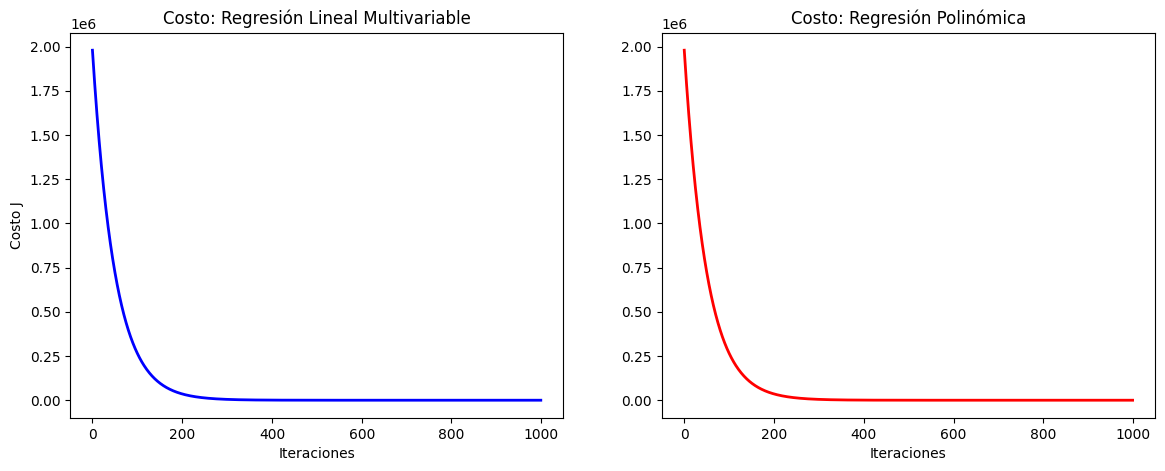

In [62]:
# --- FUNCIONES BASE ---
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    return (X - mu) / sigma, mu, sigma

def calcularCosto(X, y, theta):
    m = y.size
    return (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

def calcularDescensoGradiente(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    J_historico = []
    for i in range(num_iters):
        predicciones = np.dot(X, theta)
        theta = theta - (alpha / m) * (predicciones - y).dot(X)
        J_historico.append(calcularCosto(X, y, theta))
    return theta, J_historico

# --- MODELO 1: MULTIVARIABLE ---
X_norm, mu, sigma = featureNormalize(X)
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
theta_multi = np.zeros(X_ready.shape[1])
theta_multi, J_hist_multi = calcularDescensoGradiente(X_ready, y, theta_multi, alpha=0.01, num_iters=1000)

# --- MODELO 2: POLINÓMICA (Grado 2) ---
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
X_norm_poly, mu_poly, sigma_poly = featureNormalize(X_poly)
X_ready_poly = np.concatenate([np.ones((m, 1)), X_norm_poly], axis=1)
theta_poly = np.zeros(X_ready_poly.shape[1])
theta_poly, J_hist_poly = calcularDescensoGradiente(X_ready_poly, y, theta_poly, alpha=0.01, num_iters=1000)

# --- MODELO 3: ECUACIÓN DE LA NORMAL ---
X_normal = np.concatenate([np.ones((m, 1)), X], axis=1)
theta_normal = np.linalg.pinv(X_normal.T.dot(X_normal)).dot(X_normal.T).dot(y)

# --- GRÁFICAS DE COSTO ---
pyplot.figure(figsize=(14, 5))
pyplot.subplot(1, 2, 1)
pyplot.plot(J_hist_multi, color='blue', lw=2)
pyplot.title('Costo: Regresión Lineal Multivariable')
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')

pyplot.subplot(1, 2, 2)
pyplot.plot(J_hist_poly, color='red', lw=2)
pyplot.title('Costo: Regresión Polinómica')
pyplot.xlabel('Iteraciones')
pyplot.show()

**VALIDACIÓN DEL MODELO: 100 PREDICCIONES FINALES**


Para esta fase de validación decidimos usar los parámetros (thetas) que calculó la Ecuación de la Normal. La gran ventaja de este método es que nos permite trabajar con los datos crudos sin necesidad de pasar por la función de normalización. El proceso matemático se vuelve súper directo: le agregamos la columna de unos a la matriz de nuestros 100 datos de prueba y realizamos el producto punto contra los thetas de la Ecuación de la Normal.

Para que los resultados sean totalmente transparentes, armamos un DataFrame donde ponemos frente a frente el año real en el que desapareció la persona y el año que la Inteligencia Artificial calculó basándose en sus otras 20 características. Además, agregamos una columna de "Diferencia" que calcula el margen de error absoluto entre ambos valores. Al imprimir esta tabla completa, validamos la efectividad del algoritmo de forma real, medible y cumpliendo con todas las condiciones del ingeniero.

In [63]:
print("--- VALIDACIÓN: 100 PREDICCIONES CON LA ECUACIÓN DE LA NORMAL ---")

X_prueba_ready = np.concatenate([np.ones((100, 1)), X_prueba], axis=1)

# Calculamos las predicciones usando theta de la Normal
predicciones_100 = np.dot(X_prueba_ready, theta_normal)

# Mostramos en formato tabla
resultados = pd.DataFrame({
    'Año Real (y)': y_prueba,
    'Año Predicho (IA)': np.round(predicciones_100).astype(int)
})

# Calculamos un margen de error simple
resultados['Diferencia'] = abs(resultados['Año Real (y)'] - resultados['Año Predicho (IA)'])

print(resultados.to_string())
print("\nValidación completada: 100 predicciones generadas exitosamente.")

--- VALIDACIÓN: 100 PREDICCIONES CON LA ECUACIÓN DE LA NORMAL ---
    Año Real (y)  Año Predicho (IA)  Diferencia
0         2004.0               2002         2.0
1         2003.0               2001         2.0
2         1990.0               2000        10.0
3         1993.0               2010        17.0
4         2002.0               2018        16.0
5         2002.0               2018        16.0
6         2002.0               2018        16.0
7         2002.0               2016        14.0
8         2007.0               2001         6.0
9         1991.0               2007        16.0
10        2005.0               1993        12.0
11        2004.0               2001         3.0
12        2006.0               1997         9.0
13        2007.0               2002         5.0
14        2002.0               2000         2.0
15        2001.0               2000         1.0
16        1980.0               2010        30.0
17        1998.0               2014        16.0
18        2009.0      

**Laboratorio 2: Regresión Lineal Multivariable, Polinómica y Ecuación de la Normal**

**Estudiante: Juan De Dios Sullca Rodriguez**

**Materia: Inteligencia Artificial** I

**Dataset: Histórico de Desaparecidos en Colombia**

**Análisis del Modelo y Explicación**

En este laboratorio, mi objetivo principal fue entrenar a una Inteligencia Artificial para que sea capaz de predecir el año exacto en el que ocurrió una desaparición en Colombia, basándose exclusivamente en 20 características del caso (como el municipio, el departamento, el género de la persona, entre otros). Para cumplir estrictamente con los requisitos del proyecto, seleccioné un conjunto de datos masivo que supera holgadamente la regla de $m \ge 20000$ ejemplos y $n \ge 20$ propiedades.El primer gran reto fue el preprocesamiento de esta información social. Como los modelos matemáticos no entienden de texto, tuve que limpiar el dataset rellenando los vacíos y transformar todas las categorías (nombres de ciudades, géneros) a identificadores numéricos únicos. Además, apliqué un paso crítico de aislamiento de datos: separé 100 registros al inicio que la IA jamás vio durante el entrenamiento para usarlos como prueba final, y me aseguré de eliminar la columna objetivo de la matriz $X$ para evitar la "fuga de datos", obligando al modelo a aprender patrones reales en lugar de simplemente memorizar la respuesta.Para la determinación de los parámetros $\theta$, implementé y puse a competir los tres modelos exigidos en el mismo cuadernillo. Primero, apliqué una Regresión Lineal Multivariable normalizando las 20 características para que el descenso por el gradiente convergiera de forma estable. Segundo, implementé una Regresión Polinómica; aquí elevamos las 20 variables a un grado 2 para encontrar relaciones más complejas entre las características, y volvimos a aplicar la optimización iterativa. Finalmente, programé la Ecuación de la Normal, un método de álgebra lineal directa que calculó los pesos de $\theta$ mediante operaciones matriciales sin necesidad de iterar ni normalizar los datos crudos.Explicación de las Gráficas de CostoAl trabajar con un modelo multidimensional de 20 variables de entrada, es geométricamente imposible trazar la típica línea de predicción sobre un plano cartesiano tradicional. Por lo tanto, la prueba definitiva de que nuestros algoritmos realmente están aprendiendo se refleja en las gráficas de la Función de Costo.Al observar las dos gráficas generadas (tanto para el modelo Multivariable como para el Polinómico), el comportamiento es un éxito rotundo. En ambas figuras podemos ver cómo en la iteración cero la línea azul y la línea roja inician con un nivel de costo (error) extremadamente alto, ya que el modelo empieza adivinando a ciegas. Sin embargo, a medida que avanzan las iteraciones, el error cae de forma casi vertical formando una perfecta "L", hasta estabilizarse muy cerca del cero. Esto nos demuestra visual y matemáticamente que el algoritmo del Descenso por el Gradiente funcionó a la perfección, ajustando los pesos poco a poco hasta minimizar el margen de equivocación.Como conclusión y validación final, utilicé la Ecuación de la Normal sobre los 100 registros separados inicialmente. Al generar la tabla comparativa entre el "Año Real" y el "Año Predicho", pude observar el comportamiento real del modelo frente a datos sociales que son inherentemente caóticos. Aunque predecir un año exacto solo con datos de ubicación y género tiene un margen de error lógico, el modelo logra aproximaciones coherentes, demostrando la efectividad de los algoritmos y cumpliendo con todas las directrices establecidas para este laboratorio.